# Analiza danych przestrzennych - ćwiczenia laboratoryjne 2025/2026

Ten notatnik zalicza się do grupy zestawów zadań, na podstawie których odbywa się zaliczenie ćwiczeń i podlega zwrotowi do oceny w ustalonym na zajęciach terminie.

Uwagi i wytyczne ogólne dotyczące uzupełniania i oceny notatnika:
- Podczas wykonywania zadań należy korzystać wyłącznie z pakietów zaimportowanych na początku notatnika oraz z pakietów wchodzących w skład standardowej biblioteki Pythona, które można zaimportować samodzielnie we wskazanej komórce notatnika.
- Swoje rozwiązania należy wprowadzać wyłącznie w miejce następujących fragmentów kodu:<br/> `# YOUR CODE HERE`<br/> `raise NotImplementedError()`<br/> 
a odpowiedzi tekstowe w komórkach oznaczonych hasłem:<br/> 
`YOUR ANSWER HERE`<br/> 
Nie należy w żaden sposób modyfikować pozostałych fragmentów kodu oraz innych elementów notatnika, w szczególności dodawać lub usuwać komórek oraz zmieniać nazwy pliku.
- Jeżeli zestaw zadań wymaga skorzystania z fragmentów kodu opracowanego w ramach wcześniejszych zestawów zadań należy je umieścić we wskazanej komórce notatnika.
- Otrzymywane wyniki i odpowiedzi mają być rezultatem wykonania napisanego kodu, odpowiedzi uzupełniane manualnie nie podlegają ocenie.
- Zawarte w notatniku automatyczne testy mają charakter poglądowy. Dotyczą one wybranych aspektów zadań i mają na celu wyłapać podstawowe błędy. Przejście przez kod wszystkich testów nie oznacza, że zadanie jest wykonane w całości poprawnie i zostanie ocenione na maksymalną liczbę punktów.
- Zadania należy wykonać w taki sposób, aby podczas wykonywania kodu nie zostały wyświetlone żadne ostrzeżenia.
- Zadania, które powodują wyświetlenie komunikatu o błędzie przerywającym wykonywanie kodu nie podlegają ocenie.
- W treści niektórych zadań mogą znaleźć się przykładowe schematy ich rozwiązania lub przykładowe schematy istotnych części rozwiązania. Nie zawsze są to rozwiązania optymalne pod kątem długości kodu lub prostoty rozwiązania.  Ich celem jest klarowne rozbicie pracy na kroki i ułatwienie samodzielnej weryfikacji wyników na każdym etapie. Należy je traktować wyłącznie poglądowo, a nie jako jedyne dopuszczalne rozwiązania. Ocenie podlega poprawność merytoryczna rozwiązania, jego kompletność oraz zgodność z wymaganiami, a nie konkretna forma zapisu.
- Dla zachowania przejrzystości i łatwego odnajdywania informacji w treści zadań podawane są pełne nazwy funkcji i klas wraz z nazwami pakietów (np. `pandas.read_csv()`, `geopandas.GeoDataFrame.to_crs`). W notatniku te same obiekty są dostępne przez skrótowe aliasy (np. `pd.read_csv()`, `gpd.GeoDataFrame.to_crs`).

Uwagi i wytyczne ogólne dotyczące wizualizacji wyników:
- Wszystkie wykresy powinny być wykonane w jednolitym, przejrzystym i czytelnym stylu, posiadać odpowiednio dobrane proporcje i zakresy wartości osi.
- Figury powinny mieć ustawione białe tło, tak, aby niezależnie od ustawień notatnika wszystkie elementy wykresów były dobrze widoczne (domyślnie tło jest przeźroczyste co może powodować problemy w notatnikach z ustawionym ciemnym tłem). Rozmiar poziomy figur nie powinien przekraczać 20 cali.
- Wykresy oraz ich osie powinny mieć nadane tytuły. Jeżeli w obrębie figury znajduje się więcej niż jeden wykres to figura również powinna mieć nadany tytuł.

Przed odesłaniem zestawu zadań do oceny proszę uzupełnić komórkę z danymi autorów rozwiązania (nazwa zespołu oraz imiona, nazwiska i numery indeksów członków zespołu) oraz upewnić się, że notatnik działa zgodnie z oczekiwaniami. W tym celu należy skorzystać z opcji **Restart Kernel and Run All Cells...** dostępnej na górnej belce notatnika pod symbolem $\blacktriangleright\blacktriangleright$.

Nazwa zespołu:
Członkowie:

---

## Zestaw zadań 2: Geopandas - operacje na danych wektorowych

In [20]:
import numpy as np
import pandas as pd
import scipy as sp
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns
import geopandas as gpd
import contextily as cx

In [21]:
# Miejsce do importu pakietów wchodzących w skład standardowej biblioteki Pythona oraz ustawienie opcji wykorzystywanych pakietów

### Wczytanie danych
Poniższy kod wczytuje do zmiennych `rivers`, `cities`, `districts` oraz `voivodeships` dane z pliku data.gpkg.

In [3]:
rivers = gpd.read_file("data.gpkg", layer='rivers')
cities = gpd.read_file("data.gpkg", layer='cities')
districts = gpd.read_file("data.gpkg", layer='districts')
voivodeships = gpd.read_file("data.gpkg", layer='voivodeships')

### Zadanie 1: Mierzenie długości, pola powierzchni i odległości (10 pkt)

#### a) Długość Wisły
Korzystając z własności `geopandas.GeoSeries.length` zmierz długość Wisły w metrach oraz:
 - zapisz wynik do zmiennej `length`,
 - korzystając z funkcji `print()` wyświetl odpowiedź (pełnym zdaniem) na pytanie o długość Wisły podając odpowiedź w kilometrach z dokładnością do 3 miejsc po przecinku.

Przykładowy schemat rozwiązania:
 1) Korzystając z własności tablicy `pandas.DataFrame.loc` lub `pandas.DataFrame.iloc` wybierz komórkę tablicy zawierającą geometrię Wisły.
 2) Korzystając z własności `geopandas.GeoSeries.length` zmierz długość Wisły, wynik zapisz do zmiennej `length`.
 3) Wyświetl wynik zgodnie z instrukcją.

In [22]:
length = rivers.iloc[1,1].length
length_km = length/1000
print(f"Długość rzeki Wisła to: {length_km:.3f} km")

Długość rzeki Wisła to: 1019.758 km


In [5]:
# Komórka testowa
assert np.isclose(length, 1019757.7991167122)

#### b) Pola powierzchni województw
Korzystając z własności `geopandas.GeoSeries.area` zmierz powierzchnię województw w metrach kwadratowych oraz:
 - zapisz wyniki do tablicy `voivodeships` w kolumnie o nazwie "Pole", 
 - oblicz pole powierzchni Polski w metrach kwadartowych i zapisz wynik do zmiennej `area`,
 - korzystając z funkcji `print()` wyświetl odpowiedź na pytanie (pełnym zdaniem) o powierzchnię Polski podając odpowiedź w kilometrach kwadratowych z dokładnością do 3 miejsc po przecinku,
 - przygotuj wizualiację, na której kolor przypisany województwom jest powiązany z ich powierzchnią.

Wizualizacja powinna zawierać:
- województwa, wypełnione kolorem powiązanym z ich powierzchnią (ciągła skala kolorów),

Przygotuj figurę zgodnie z wytycznymi z nagłówka notatnika. Ustaw parametry wykresu oraz wizualizowanych obiektów (wielkość figury, kolory, grubość linii, wielkość punktów itp.) tak aby wygenerowana mapa była przejrzysta i czytelna.

Przykładowy schemat rozwiązania:
 1) Korzystając z własności `geopandas.GeoSeries.area` dokonaj pomiaru pola powierzchni województw, wynik zapisz do tablicy `voivodeships` jako kolumnę "Pole".
 2) Korzystając z funkcji `numpy.sum()` oblicz pole powierzchni Polski jako sumaryczne pole powierzchni wszystkich województw, wynik zapisz do zmiennej `area`.
 3) Wyświetl wynik zgodnie z instrukcją.

In [6]:
pole = voivodeships.area
voivodeships["Pole"] = pole
area = pole.sum()
area_km = area/1_000_000
print(f"Pole powierzchni Polski wynosi: {area_km:.3f} km²")

Pole powierzchni Polski wynosi: 312506.645 km²


In [7]:
# Komórka testowa
assert np.all(np.isclose(np.sort(voivodeships["Pole"].values), np.sort(np.array([1.99361725e+10, 1.79475269e+10, 2.51340028e+10, 1.39898166e+10,
                                                               3.55292977e+10, 1.51660383e+10, 9.39998646e+09, 1.78437052e+10,
                                                               2.01931654e+10, 1.83069651e+10, 2.41505782e+10, 2.97972921e+10,
                                                               2.29033672e+10, 1.81944352e+10, 1.23170381e+10, 1.16972569e+10]))))
assert np.isclose(voivodeships[voivodeships["Nazwa"]=="małopolskie"]["Pole"].values[0], 15166038294.192154)
assert np.isclose(voivodeships[voivodeships["Nazwa"]=="pomorskie"]["Pole"].values[0], 18306965109.079857)
assert np.isclose(area, 312506644577.3843)

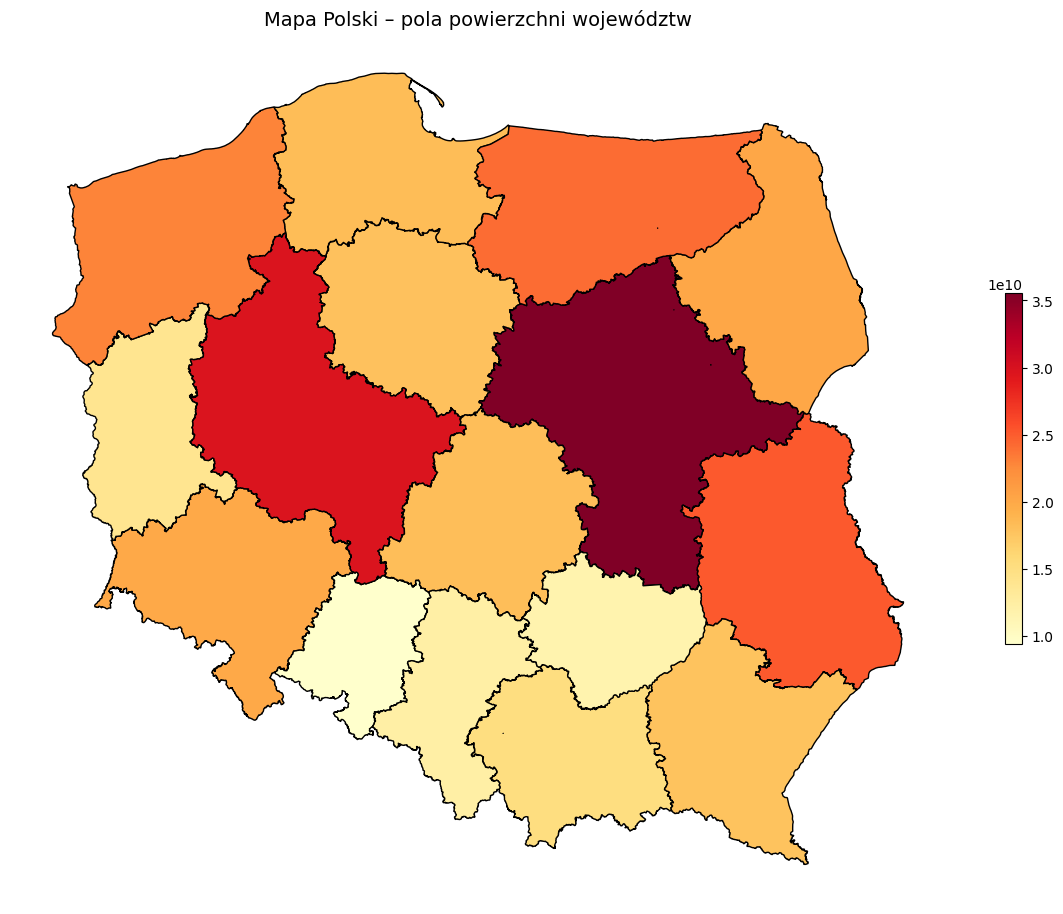

In [8]:
fig, ax = plt.subplots(figsize=(12,12))
voivodeships.plot(ax=ax, column = "Pole",cmap="YlOrRd", edgecolor="black", linewidth=1, zorder=1, alpha=1, legend = True, legend_kwds={'shrink': 0.3}  )
#cx.add_basemap(ax=ax, crs=districts.crs.to_string(), source = cx.providers.CartoDB.Voyager, zoom=7, zorder=0)
ax.set_title("Mapa Polski – pola powierzchni województw", fontsize=14)
ax.set_xlabel("Współrzędne X (m)")
ax.set_ylabel("Współrzędne Y (m)")
ax.set_axis_off()
plt.tight_layout()
plt.show()

#### c) Odległość miast od Krakowa
Korzystając z funkcji `geopandas.GeoSeries.distance()` zmierz odległość poszczególnych miast od Krakowa w metrach oraz:
 - zapisz wyniki do tablicy `cities` w kolumnie o nazwie "Odległość od Krakowa", 
 - sprawdź w jakiej odległości od Krakowa w kilometrach leży Poznań i zapisz wynik do zmiennej `distance`,
 - korzystając z funkcji `print()` wyświetl odpowiedź na pytanie (pełnym zdaniem) w jakiej odległości wyrażonej w kilometrach od Krakowa leży Poznań,
 - przygotuj wizualiację, na której kolor przypisany miastom jest powiązany z ich odległością od Krakowa. 

Wizualizacja powinna zawierać:
- kontury województw, bez wypełnienia,
- lokalizaje miast, których kolor jest powiązany z ich odległością od Krakowa (ciągła skala kolorów).

Przygotuj figurę zgodnie z wytycznymi z nagłówka notatnika. Ustaw parametry wykresu oraz wizualizowanych obiektów (wielkość figury, kolory, grubość linii, wielkość punktów itp.) tak aby wygenerowana mapa była przejrzysta i czytelna.

Przykładowy schemat rozwiązania:
 1) Korzystając z funkcji `pandas.DataFrame.eq()`, `pandas.DataFrame.isin()` lub metody logicznej selekcji po kolumnie atrybutowej sprawdź, w którym wierszu tablicy znajduje się Kraków.
 2) Korzystając z własności tablicy `pandas.DataFrame.loc` lub `pandas.DataFrame.iloc` wybierz komórkę tablicy zawierającą lokalizację Krakowa.
 3) Korzystając z funkcji `geopandas.GeoSeries.distance()` dokonaj pomiaru odległości miast od Krakowa, wynik zapisz do tablicy `cities` jako kolumnę "Odległość od Krakowa".
 4) Korzystając z funkcji `pandas.DataFrame.eq()`, `pandas.DataFrame.isin()` lub metody logicznej selekcji po kolumnie atrybutowej sprawdź, w którym wierszu tablicy znajduje się Poznań.
 5) Korzystając z własności tablicy `pandas.DataFrame.loc` lub `pandas.DataFrame.iloc` wybierz komórkę tablicy zawierającą odległość Poznania od Krakowa, dokonaj konwersji jednostek i zapisz wynik do zmiennej `distance`.
 6) Wyświetl wynik zgodnie z instrukcją.

In [9]:
krakow = cities.loc[cities["Nazwa"]=="Kraków"].iloc[0,1]
dist = krakow.distance(cities.iloc[:,1])
cities["Odległość od Krakowa"] = dist
poznan_m = cities.loc[cities["Nazwa"]=="Poznań"].iloc[0,2]
distance = poznan_m/1000
print(f"Odległość Poznania od Krakowa to: {distance:.3f} km")

Odległość Poznania od Krakowa to: 334.605 km


In [10]:
# Komórka testowa
assert np.isclose(cities["Odległość od Krakowa"].min(), 0.0)
assert np.isclose(cities["Odległość od Krakowa"].max(), 579020.726082644)
assert np.isclose(cities["Odległość od Krakowa"].mean(), 271127.08178774477)
assert np.isclose(distance, 334.60495145299524)

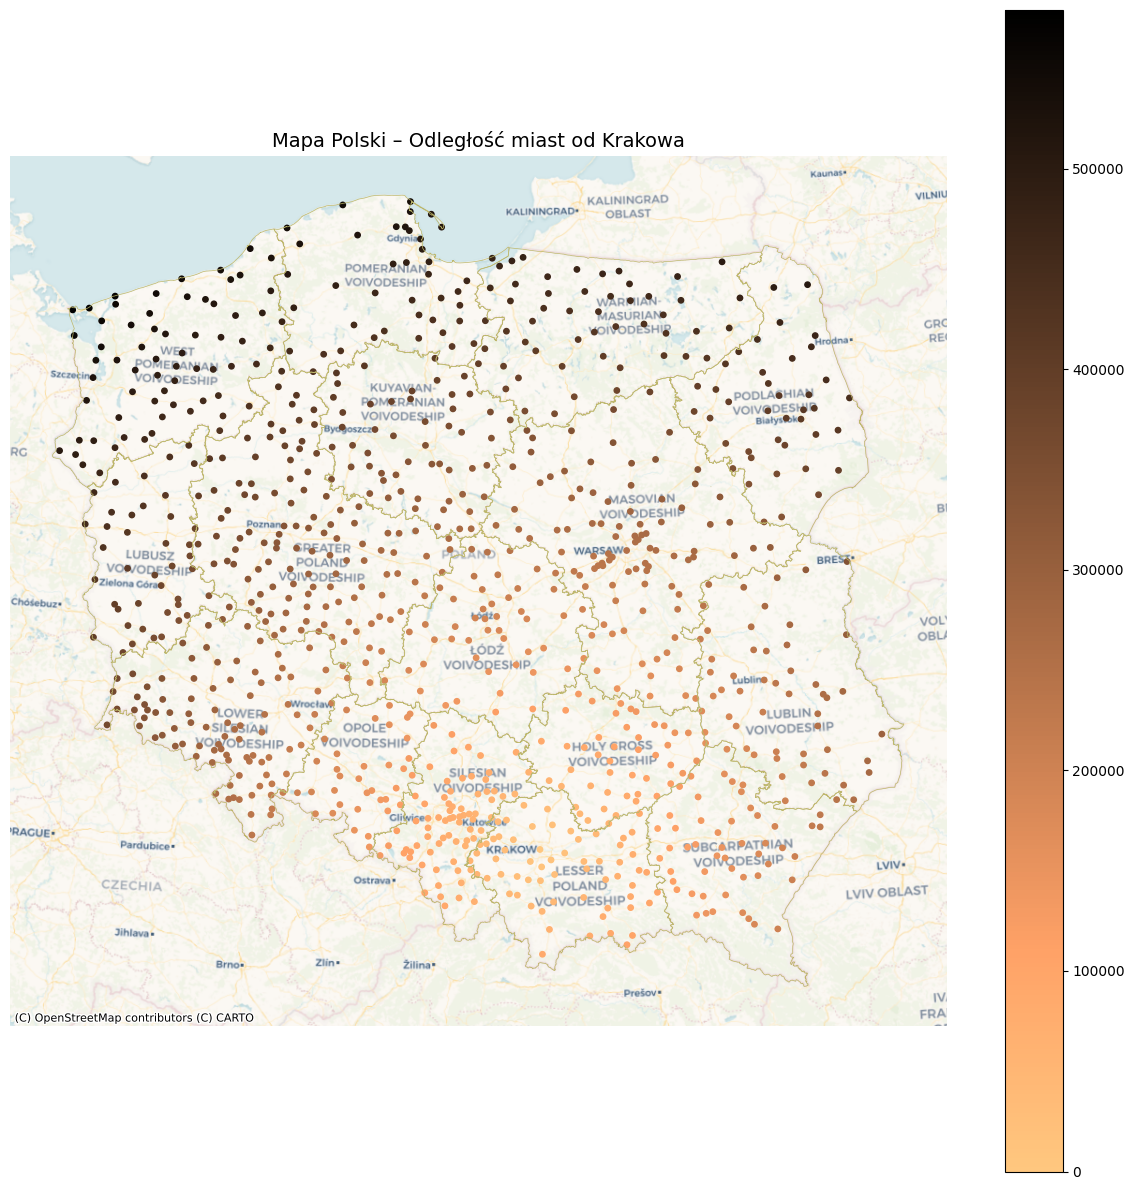

In [11]:
fig, ax = plt.subplots(figsize=(12,12))
cities.plot(ax=ax, column = "Odległość od Krakowa",cmap="copper_r",markersize=15, zorder=1, legend = True)
voivodeships.boundary.plot(ax=ax, edgecolor="darkkhaki", linewidth=0.5, zorder=2)
cx.add_basemap(ax=ax, crs=districts.crs.to_string(), source = cx.providers.CartoDB.Voyager, zoom=7, zorder=0)
ax.set_title("Mapa Polski – Odległość miast od Krakowa", fontsize=14)
ax.set_xlabel("Współrzędne X (m)")
ax.set_ylabel("Współrzędne Y (m)")
ax.set_axis_off()
plt.tight_layout()
plt.show()

### Zadanie 2: Wykorzystanie prostych operacji geometrycznych (10 pkt)

#### a) Miasta blisko Wisły

Korzystając z funkcji `geopandas.GeoSeries.buffer()` oraz `geopandas.GeoSeries.within()` sprawdź, które miasta leżą bliżej niż 20 km od Wisły oraz:
 - zapisz wyniki do tablicy `cities` w kolumnie o nazwie "Blisko Wisły" (True/False),
 - oblicz ile miast leży bliżej niż 20 km od Wisły i zapisz wynik do zmiennej `cities_close_to_vistula`,
 - korzystając z funkcji `print()` wyświetl odpowiedź na pytanie (pełnym zdaniem) ile miast leży bliżej niż 20 km od Wisły,
 - przygotuj wizualiację, na której oznaczony zostanie obszar znajdujący się bliżej niż 20 km od Wisły, a znajdujące się w tym obszarze miasta będą wyróżnione kolorem względem pozostałych miast.

Wizualizacja powinna zawierać:
- województwa, wypełnione jednolitym kolorem,
- miasta, w jednym z dwóch wybranych kolorów w zależności od spełnienia analizowanego kryterium.
- rzeki wypełnione jednolitym kolorem,
- oznaczenie terenu leżącego nie dalej niż 20 km od Wisły.

Ustaw parametry wykresu oraz wizualizowanych obiektów (wielkość figury, kolory, grubość linii, wielkość punktów itp.) tak aby wygenerowana mapa była przejrzysta i czytelna.

Przykładowy schemat rozwiązania:
 1) Korzystając z własności tablicy `pandas.DataFrame.loc` lub `pandas.DataFrame.iloc` lub z metody logicznej selekcji po kolumnie atrybutowej wybierz wiersz tablicy dotyczący Wisły.
 2) Korzystajac z funkcji `geopandas.GeoSeries.buffer()` stwórz jednowierszową tablicę zawierającą geometrię poligonu obejmującego strefę 20km od Wisły.
 3) Korzystając z funkcji  `geopandas.GeoSeries.within()` sprawdź, które miasta leżą nie dalej niż 20 km od Wisły (jako argument funkcji przekaż samą geometrię obiektu), wynik zapisz do tablicy `cities` jako kolumnę "Blisko Wisły". 
 4) Korzystając z funkcji `numpy.sum()` policz ile miast leży nie dalej niż 20km od Wisły jako sumę wartości przygotowanej kolumny (w operacji sumowania True=1, False=0), wynik zapisz do zmiennej `cities_close_to_vistula`.
 5) Wyświetl wynik zgodnie z instrukcją.

In [12]:
wisla = rivers.iloc[1,1]
wisla_obszar = wisla.buffer(20_000)
blisko_wisly = cities.within(wisla_obszar)
cities["Blisko Wisły"] = blisko_wisly
cities_close_to_vistula = blisko_wisly.sum()
print(f"Ilość miast leżących bliżej niż 20 km od Wisły to: {cities_close_to_vistula}")

Ilość miast leżących bliżej niż 20 km od Wisły to: 148


In [13]:
# Komórka testowa
assert cities_close_to_vistula == 148

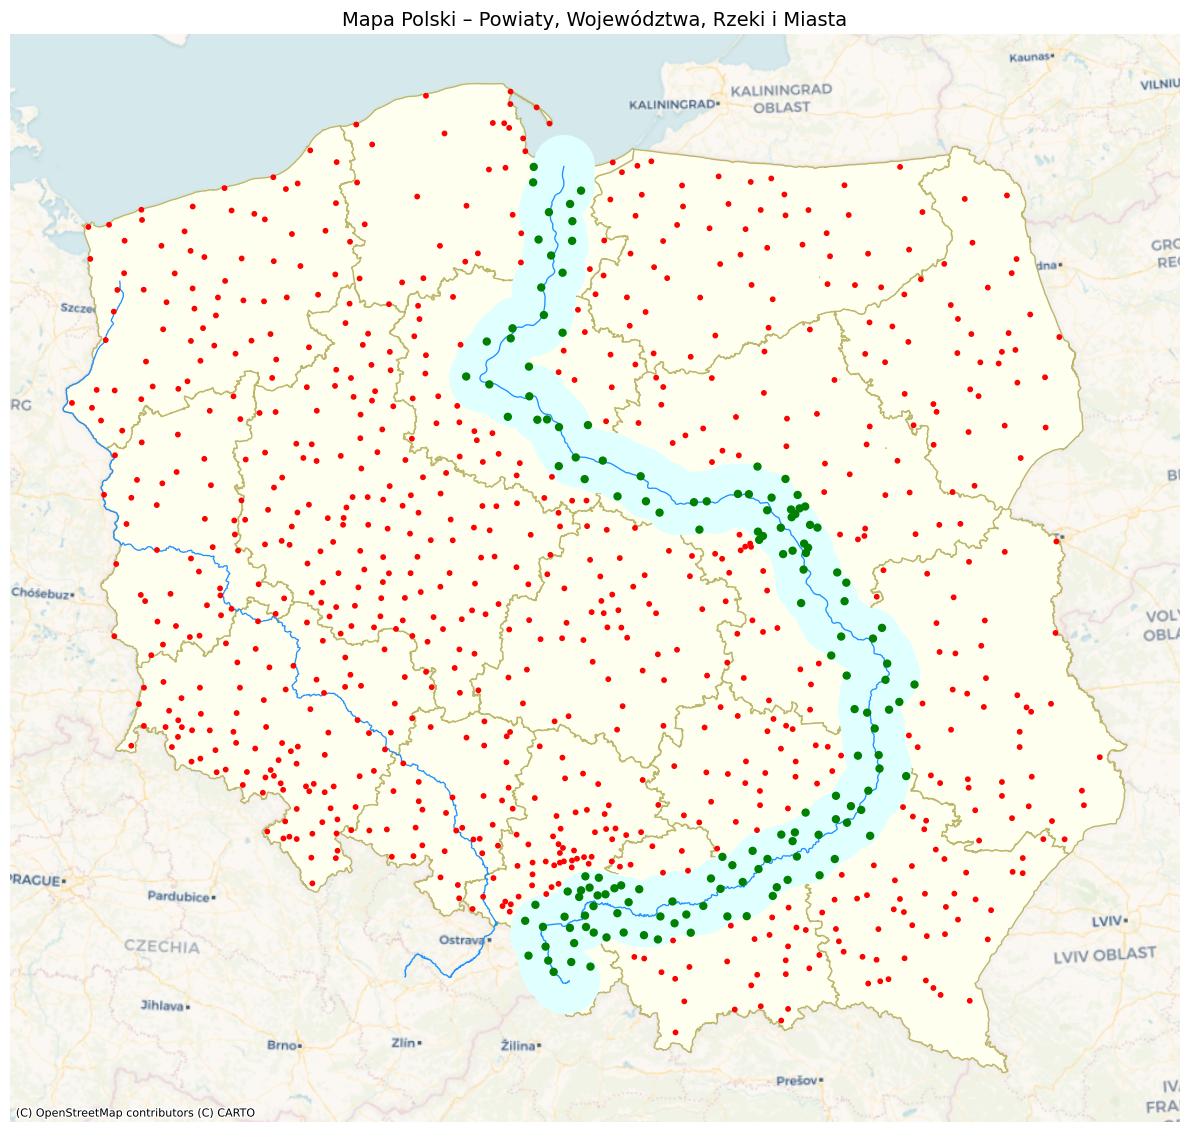

In [14]:
cities_col = np.where(cities["Blisko Wisły"], "green", "red")
cities_size = np.where(cities["Blisko Wisły"], 25, 10)

fig, ax = plt.subplots(figsize=(12,12))
voivodeships.plot(ax=ax, color = "ivory", edgecolor="darkkhaki", linewidth=1, zorder=2)
rivers.plot(ax=ax, color = "dodgerblue", linewidth=0.95, zorder=4)
cities.plot(ax=ax, color = cities_col, markersize=cities_size, zorder=5)
gpd.GeoSeries([wisla_obszar]).plot(ax=ax, color = "lightcyan", linewidth = 0.5, zorder=3)
cx.add_basemap(ax=ax, crs=districts.crs.to_string(), source = cx.providers.CartoDB.Voyager, zoom=7, zorder=0)
ax.set_title("Mapa Polski – Powiaty, Województwa, Rzeki i Miasta", fontsize=14)
ax.set_xlabel("Współrzędne X (m)")
ax.set_ylabel("Współrzędne Y (m)")
ax.set_axis_off()
plt.tight_layout()
plt.show()

#### b) Województwa, przez które przepływa Odra
Korzystając z funkcji `geopandas.GeoSeries.intersects()` sprawdź, przez które województwa przepływa Odra oraz:
 - zapisz wyniki do tablicy `voivodeships` w kolumnie o nazwie "Odra w obrębie" (True/False) oraz do zmiennej `voivodeships_with_oder` (lista województw, przez które przepływa Odra),
 - korzystając z funkcji `print()` wyświetl odpowiedź na pytanie (pełnym zdaniem) przez które województa przepływa Odra,
 - przygotuj wizualiację, na której województwa przez które przepływa Odra będą wyróżnione kolorem względem pozostałych województw.

Wizualizacja powinna zawierać:
- województwa, wypełnione jednym z dwóch wybranych kolorów w zależności od spełnienia analizowanego kryterium,
- miasta, wypełnione jednolitym kolorem,
- rzeki wypełnione jednolitym kolorem.

Ustaw parametry wykresu oraz wizualizowanych obiektów (wielkość figury, kolory, grubość linii, wielkość punktów itp.) tak aby wygenerowana mapa była przejrzysta i czytelna.

Przykładowy schemat rozwiązania:
 1) Korzystając z własności tablicy `pandas.DataFrame.loc`, `pandas.DataFrame.iloc` wybierz komórkę tablicy zawierającą geometrię Odry.
 2) Korzystajac z funkcji `geopandas.GeoSeries.intersects()` sprawdź, przez które województwa przepływa Odra, wynik zapisz do tablicy `voivodeships` jako kolumnę "Odra w obrębie".
 4) Korzystając z własności tablicy `pandas.DataFrame.loc` lub `pandas.DataFrame.iloc` oraz z metody logicznej selekcji po kolumnie atrybutowej wybierz województwa przez które przepływa Odra, wynik skonwertuj do listy i zapisz do zmiennej `voivodeships_with_oder`.
 5) Wyświetl wynik zgodnie z instrukcją.

In [15]:
odra = rivers.iloc[0,1]
odra_plynie = voivodeships["geometry"].intersects(odra)
voivodeships["Odra w obrębie"] = odra_plynie
voivodeships_with_oder = voivodeships.loc[voivodeships["Odra w obrębie"] == True].iloc[:,0].tolist()
print(f"Odra przepływa przez województwa: {', '.join(voivodeships_with_oder)}.")

Odra przepływa przez województwa: dolnośląskie, lubuskie, opolskie, zachodniopomorskie, śląskie.


In [16]:
# Komórka testowa
assert sorted(voivodeships_with_oder) == ['dolnośląskie', 'lubuskie', 'opolskie', 'zachodniopomorskie', 'śląskie']

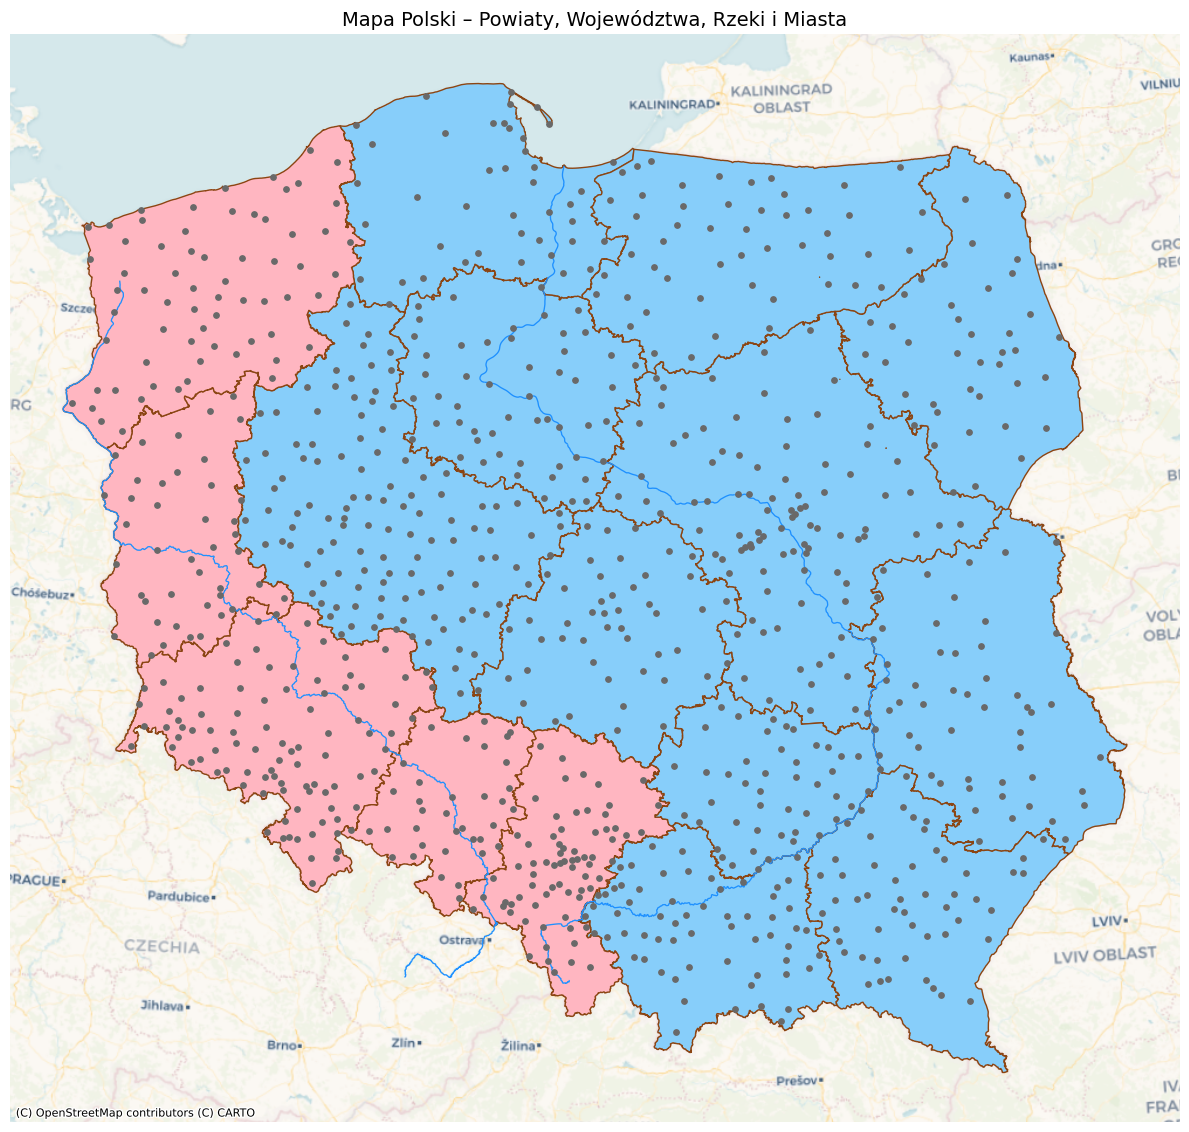

In [17]:
woj_color = np.where(voivodeships["Odra w obrębie"], "lightpink", "lightskyblue")

fig, ax = plt.subplots(figsize=(12,12))
voivodeships.plot(ax=ax, color = woj_color, edgecolor="saddlebrown", linewidth=1, zorder=2)
rivers.plot(ax=ax, color = "dodgerblue", linewidth=0.95, zorder=4)
cities.plot(ax=ax, color = "dimgrey", markersize=15, zorder=5)
cx.add_basemap(ax=ax, crs=districts.crs.to_string(), source = cx.providers.CartoDB.Voyager, zoom=7, zorder=0)
ax.set_title("Mapa Polski – Powiaty, Województwa, Rzeki i Miasta", fontsize=14)
ax.set_xlabel("Współrzędne X (m)")
ax.set_ylabel("Współrzędne Y (m)")
ax.set_axis_off()
plt.tight_layout()
plt.show()

#### c) Długość Wisły w obrębie województwa Mazowieckiego
Korzystając z funkcji `geopandas.clip()` oraz z własności `geopandas.GeoSeries.length` zmierz długość Wisły w metrach w obrębie województwa Mazowieckiego:
 - zapisz wynik do zmiennej `length_masovian`,
 - korzystając z funkcji `print()` wyświetl odpowiedź (pełnym zdaniem) na pytanie o długość Wisły w obrębie województwa Mazowieckiego podając odpowiedź w kilometrach z dokładnością do 3 miejsc po przecinku.

Przykładowy schemat rozwiązania:
 1) Korzystając z własności tablicy `pandas.DataFrame.loc` lub `pandas.DataFrame.iloc` wybierz wiersze tablic zawierające informacje o Wiśle i województwie mazowieckim (jako osobne zmienne).
 2) Korzystając z funkcji `geopandas.clip()` dotnij Wisłę do granic województwa mazowieckiego.
 3) Korzystając z własności tablicy `pandas.DataFrame.loc` lub `pandas.DataFrame.iloc` wybierz komórkę tablicy zawierającą geometrię Wisły.
 4) Korzystając z własności `geopandas.GeoSeries.length` dokonaj pomiaru długości, wynik zapisz do zmiennej `length_masovian`.
 5) Wyświetl wynik zgodnie z instrukcją.

In [18]:
wisla = gpd.GeoSeries(rivers.iloc[1,1], crs = voivodeships.crs)
mazowieckie = voivodeships.loc[voivodeships["Nazwa"] == "mazowieckie", "geometry"]
wisla_maz = gpd.clip(wisla, mazowieckie)
length_masovian = wisla_maz.length.iloc[0]
print(f"Długość Wisły w województwie Mazowieckim to: {length_masovian/1_000:.3f} km")

Długość Wisły w województwie Mazowieckim to: 264.540 km


In [19]:
# Komórka testowa
assert np.isclose(length_masovian, 264540.1708603703)